In [1]:
import glob
import os.path
import random
import numpy as np
import json
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import zipfile

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torchvision import models,transforms
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

DEVICE ="cuda"
BATCH_SIZE=128


In [2]:
os.listdir('../input/dogs-vs-cats-redux-kernels-edition')
os.makedirs('../data', exist_ok=True)
base_dir = '../input/dogs-vs-cats-redux-kernels-edition'
train_dir = '../data/train'
test_dir = '../data/test'
with zipfile.ZipFile(os.path.join(base_dir, 'train.zip')) as train_zip:
    train_zip.extractall('../data')
    
with zipfile.ZipFile(os.path.join(base_dir, 'test.zip')) as test_zip:
    test_zip.extractall('../data')


In [3]:
train_list = glob.glob(os.path.join(train_dir,'*.jpg'))
test_list = glob.glob(os.path.join(test_dir, '*.jpg'))

train_list, val_list = train_test_split(train_list, test_size=0.1)


ValueError: With n_samples=0, test_size=0.1 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [4]:
print(train_list[:10])
print(test_list[:10])


[]
[]


In [5]:
class ImageTransform():
    def __init__(self):
        self.data_transform = {
            'train': transforms.Compose([
                # transforms.Resize((224,224)),
                transforms.RandomResizedCrop(224),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
            ]),
            'test': transforms.Compose([
                transforms.Resize(250),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
            ])
        }
    def __call__(self, img, phase):
        return self.data_transform[phase](img)


In [6]:
class MyDataset(data.Dataset):
    def __init__(self,file_path_list,transform,phase):
        self.file_list = file_path_list
        self.transform = transform
        self.phase = phase
        
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self,idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img,self.phase)
        
        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label=1
        elif label == 'cat':
            label=0
        else:
            # これは、phase==testの場合、この場合そのままidを渡すことになる
            pass
            
        return img_transformed,label


In [7]:
transform = ImageTransform()

train_dataset = MyDataset(train_list, transform=transform, phase='train')
train_dataloader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

val_dataset = MyDataset(val_list, transform=transform, phase='test')
val_dataloader = data.DataLoader(val_dataset,batch_size=BATCH_SIZE, shuffle = True, num_workers=4, pin_memory=True)

test_dataset = MyDataset(test_list,transform=transform,phase='test')
test_dataloader = data.DataLoader(test_dataset,batch_size=BATCH_SIZE, shuffle = True, num_workers=4, pin_memory=True)


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [8]:
class Cnn(nn.Module):
    def __init__(self):
        super(Cnn,self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3,16,kernel_size=3, padding=0,stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(16,32, kernel_size=3, padding=0, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
            )
        
        self.layer3 = nn.Sequential(
            nn.Conv2d(32,64, kernel_size=3, padding=0, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        
        self.fc1 = nn.Linear(3*3*64,10)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(10,2)
        self.relu = nn.ReLU()
        
        
    def forward(self,x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.view(out.size(0),-1)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out


In [9]:
model = Cnn()
model.train()


Cnn(
  (layer1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=576, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=10, out_features=2, bias=True)
  (re

In [10]:
from tqdm import tqdm

# 分類問題用のtrain_model
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    def _train(epoch):
        epoch_loss = 0
        epoch_accuracy = 0    
        # tqdmで進捗バーを表示し、postfixで訓練の途中結果を表示
        with tqdm(train_loader, desc="Training", leave=True) as pbar:
            for data, label in pbar:
                data = data.to(DEVICE)
                label = label.to(DEVICE)
                
                output = model(data)
                loss = criterion(output, label)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                acc = (output.argmax(dim=1) == label).float().mean()
                epoch_accuracy += acc / len(train_loader)
                epoch_loss += loss / len(train_loader)
                
                # postfixでtrain_loss, acc, learning rateを表示
                pbar.set_postfix({
                    'Train Loss': epoch_loss.item(),
                    'Train Accuracy': epoch_accuracy.item(),
                    'Learning Rate': optimizer.param_groups[0]['lr']
                })
        
        print(f"Epoch: {epoch+1}, Train Accuracy: {epoch_accuracy:.4f}, Train Loss: {epoch_loss:.4f}")
    def _val(epoch):
        # 検証の進行状況を表示
        epoch_val_accuracy = 0
        epoch_val_loss = 0
        with torch.no_grad():
            with tqdm(val_loader, desc="Validation", leave=True) as pbar:
                for data, label in pbar:
                    data = data.to(DEVICE)
                    label = label.to(DEVICE)
                    
                    val_output = model(data)
                    val_loss = criterion(val_output, label)
                    
                    acc = (val_output.argmax(dim=1) == label).float().mean()
                    epoch_val_accuracy += acc / len(val_loader)
                    epoch_val_loss += val_loss / len(val_loader)
                    
                    # postfixでval_loss, val_accを表示
                    pbar.set_postfix({
                        'Val Loss': epoch_val_loss.item(),
                        'Val Accuracy': epoch_val_accuracy.item()
                    })
        
        print(f"Epoch: {epoch+1}, Validation Accuracy: {epoch_val_accuracy:.4f}, Validation Loss: {epoch_val_loss:.4f}")

    

    
    model = model.to(DEVICE)

    _val(-1)
    
    for epoch in range(epochs):

        print(f"Epoch {epoch+1}/{epochs}")
        
        _train(epoch)
        
        _val(epoch)


In [11]:
optimizer= optim.Adam(params = model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()


In [12]:
train_model(model,train_dataloader,val_dataloader,optimizer,criterion,10)


NameError: name 'train_dataloader' is not defined

In [13]:
dog_probs = []
model.eval()
with torch.no_grad():
    for data, fileid in test_dataloader:
        data = data.to(DEVICE)
        preds = model(data)
        preds_list = F.softmax(preds, dim=1)[:, 1].tolist()
        dog_probs += list(zip(list(fileid), preds_list))

dog_probs.sort(key = lambda x : int(x[0]))
dog_probs[:10]


NameError: name 'test_dataloader' is not defined

In [14]:
idx = list(map(lambda x: x[0],dog_probs))
prob = list(map(lambda x: x[1],dog_probs))

submission = pd.DataFrame({'id':idx,'label':prob})
submission


,id,label


In [15]:
submission.to_csv('result.csv',index=False)


IndexError: Cannot choose from an empty sequence

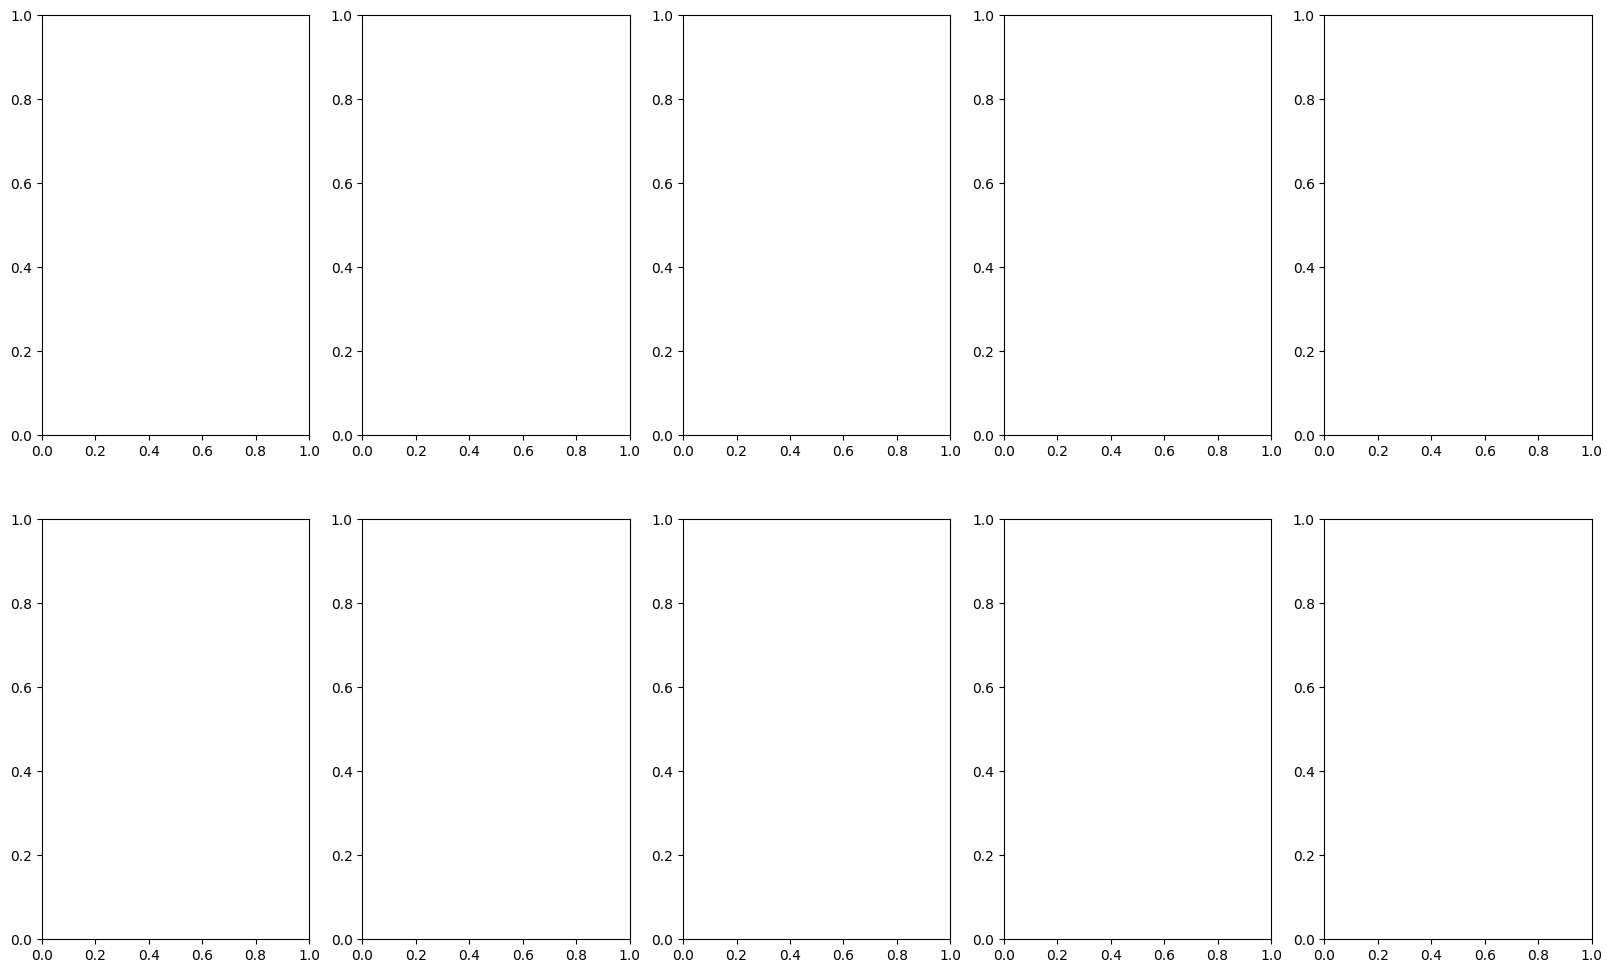

In [16]:
import random

id_list = []
class_ = {0: 'cat', 1: 'dog'}

fig, axes = plt.subplots(2, 5, figsize=(20, 12), facecolor='w')

for ax in axes.ravel():
    
    i = random.choice(submission['id'].values)
    
    label = submission.loc[submission['id'] == i, 'label'].values[0]
    if label > 0.5:
        label = 1
    else:
        label = 0
        
    img_path = os.path.join(test_dir, '{}.jpg'.format(i))
    img = Image.open(img_path)
    
    ax.set_title(class_[label])
    ax.imshow(img)
